# 1.1. Выбор датасета

Импортируем базовые необходимые бибилиотеки

In [1]:
#1. Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from wordcloud import WordCloud

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

Загружаем датасет

In [2]:
#2.Загрузка датасета

import kagglehub

path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")

# Поиск CSV файла
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_files[0])

# Загрузка данных
df = pd.read_csv(csv_path)

print(f"Количество записей: {len(df)}")
print(f"Столбцы: {df.columns.tolist()}")

100%|██████████| 350M/350M [00:10<00:00, 35.4MB/s]

Extracting files...


Количество записей: 487235
Столбцы: ['text', 'generated']


3. Обоснование выбора датасета
ОБОСНОВАНИЕ ВЫБОРА ДАТАСЕТА:

Датасет "AI vs Human Text" выбран по следующим причинам:

1. АКТУАЛЬНОСТЬ ЗАДАЧИ:
   - Проблема определения авторства текста становится критически
     важной с развитием LLM (GPT, Claude, Gemini)
   - Используется в образовании, журналистике, научных публикациях, а также в соцестях и маркетинге

2. ХАРАКТЕРИСТИКИ ДАННЫХ:
   - 487,235 записей — достаточный размер для обучения
   - Бинарная классификация (0=человек, 1=ИИ) — простой и понятный формат
   - Тексты разной длины и стиля — богатый материал для feature engineering

3. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   - Результат проекта можно использовать в реальных системах проверки

4. ПОТЕНЦИАЛ ДЛЯ АНАЛИЗА:
   - Можно выявить статистические различия между текстами людей и ИИ
   - Интересные паттерны: длина предложений, лексическое разнообразие, пунктуация


In [3]:
#4. Первичный осмотр данных
# Первые записи
print(df.head())

# Информация о датасете
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

# Типы данных
print(df.dtypes)

                                                text  generated
0  Cars. Cars have been around since they became ...        0.0
1  Transportation is a large necessity in most co...        0.0
2  "America's love affair with it's vehicles seem...        0.0
3  How often do you ride in a car? Do you drive a...        0.0
4  Cars are a wonderful thing. They are perhaps o...        0.0
Количество строк: 487235
Количество столбцов: 2
text          object
generated    float64
dtype: object


# 1.2. EDA-анализ

In [4]:
#5. Анализ пропусков и выбросов

# Проверка пропусков
missing_info = pd.DataFrame({
    'Пропущено': df.isnull().sum(),
    'Процент': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_info)

# Удаление строк с пропусками
df = df.dropna()
print(f"\nПосле удаления пропусков: {len(df)} записей")

# Проверка дубликатов
duplicates = df.duplicated().sum()
print(f"\nДубликатов найдено: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"После удаления дубликатов: {len(df)} записей")

# Проверка выбросов по длине текста
df['text_length'] = df['text'].str.len()

Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df['text_length'] < lower_bound) |
                  (df['text_length'] > upper_bound)).sum()
print(f"\nВыбросов по длине текста: {outliers_count} ({outliers_count/len(df)*100:.2f}%)")

           Пропущено  Процент
text               0      0.0
generated          0      0.0

После удаления пропусков: 487235 записей

Дубликатов найдено: 0

Выбросов по длине текста: 18702 (3.84%)



Класс '0' (Человек): 305797 (62.76%)
Класс '1' (ИИ): 181438 (37.24%)
Баланс классов: 1.69


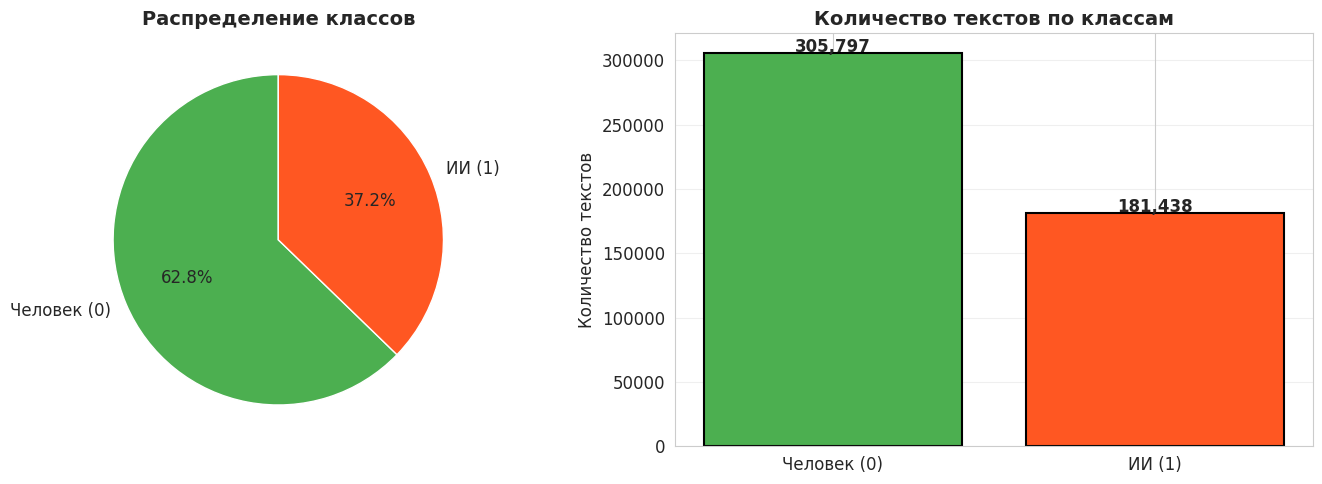

In [5]:
#6. Распределение классов

class_counts = df['generated'].value_counts()
class_percentages = df['generated'].value_counts(normalize=True) * 100

print(f"\nКласс '0' (Человек): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Класс '1' (ИИ): {class_counts[1]} ({class_percentages[1]:.2f}%)")
print(f"Баланс классов: {class_counts[0]/class_counts[1]:.2f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Диаграмма-пирог
colors = ['#4CAF50', '#FF5722']
ax1.pie(class_counts, labels=['Человек (0)', 'ИИ (1)'],
        autopct='%1.1f%%', colors=colors, startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('Распределение классов', fontsize=14, fontweight='bold')

# Бар-чарт
ax2.bar(['Человек (0)', 'ИИ (1)'], class_counts.values,
        color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Количество текстов')
ax2.set_title('Количество текстов по классам', fontsize=14, fontweight='bold')

# Добавление значений на столбцы
for i, v in enumerate(class_counts.values):
    ax2.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
#7. Анализ длин текстов
# Добавляем признак длины текста
df['text_length'] = df['text'].str.len()
# Считаем количество слов в каждом тексте. Изначально планировалось через функцию split, но столкнулась с нехваткой ОЗУ. Подумала, что альтернативно можно за слово считать полседовательность непробельных символов подряд
df['word_count'] = df['text'].str.count(r'\S+')

# Статистика
print("\nСтатистика длины текста (символы):")
print(df['text_length'].describe())

print("\nСтатистика количества слов:")
print(df['word_count'].describe())

# Статистика по классам
print("\n📊 Статистика по классам:")
for label in [0, 1]:
    class_name = "Человек" if label == 0 else "ИИ"
    subset = df[df['generated'] == label]
    print(f"\n{class_name} ({label}):")
    print(f"  Средняя длина текста: {subset['text_length'].mean():.0f} символов")
    print(f"  Медианная длина: {subset['text_length'].median():.0f}")
    print(f"  Среднее количество слов: {subset['word_count'].mean():.0f}")


Статистика длины текста (символы):
count    487235.000000
mean       2269.586592
std         988.814028
min           1.000000
25%        1583.000000
50%        2102.000000
75%        2724.000000
max       18322.000000
Name: text_length, dtype: float64

Статистика количества слов:
count    487235.000000
mean        393.096214
std         168.593328
min           0.000000
25%         278.000000
50%         363.000000
75%         471.000000
max        1668.000000
Name: word_count, dtype: float64

📊 Статистика по классам:

Человек (0):
  Средняя длина текста: 2355 символов
  Медианная длина: 2156
  Среднее количество слов: 422

ИИ (1):
  Средняя длина текста: 2126 символов
  Медианная длина: 2048
  Среднее количество слов: 344


/tmp/ipykernel_2977/25882010.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(data_for_box, labels=['Человек', 'ИИ'],


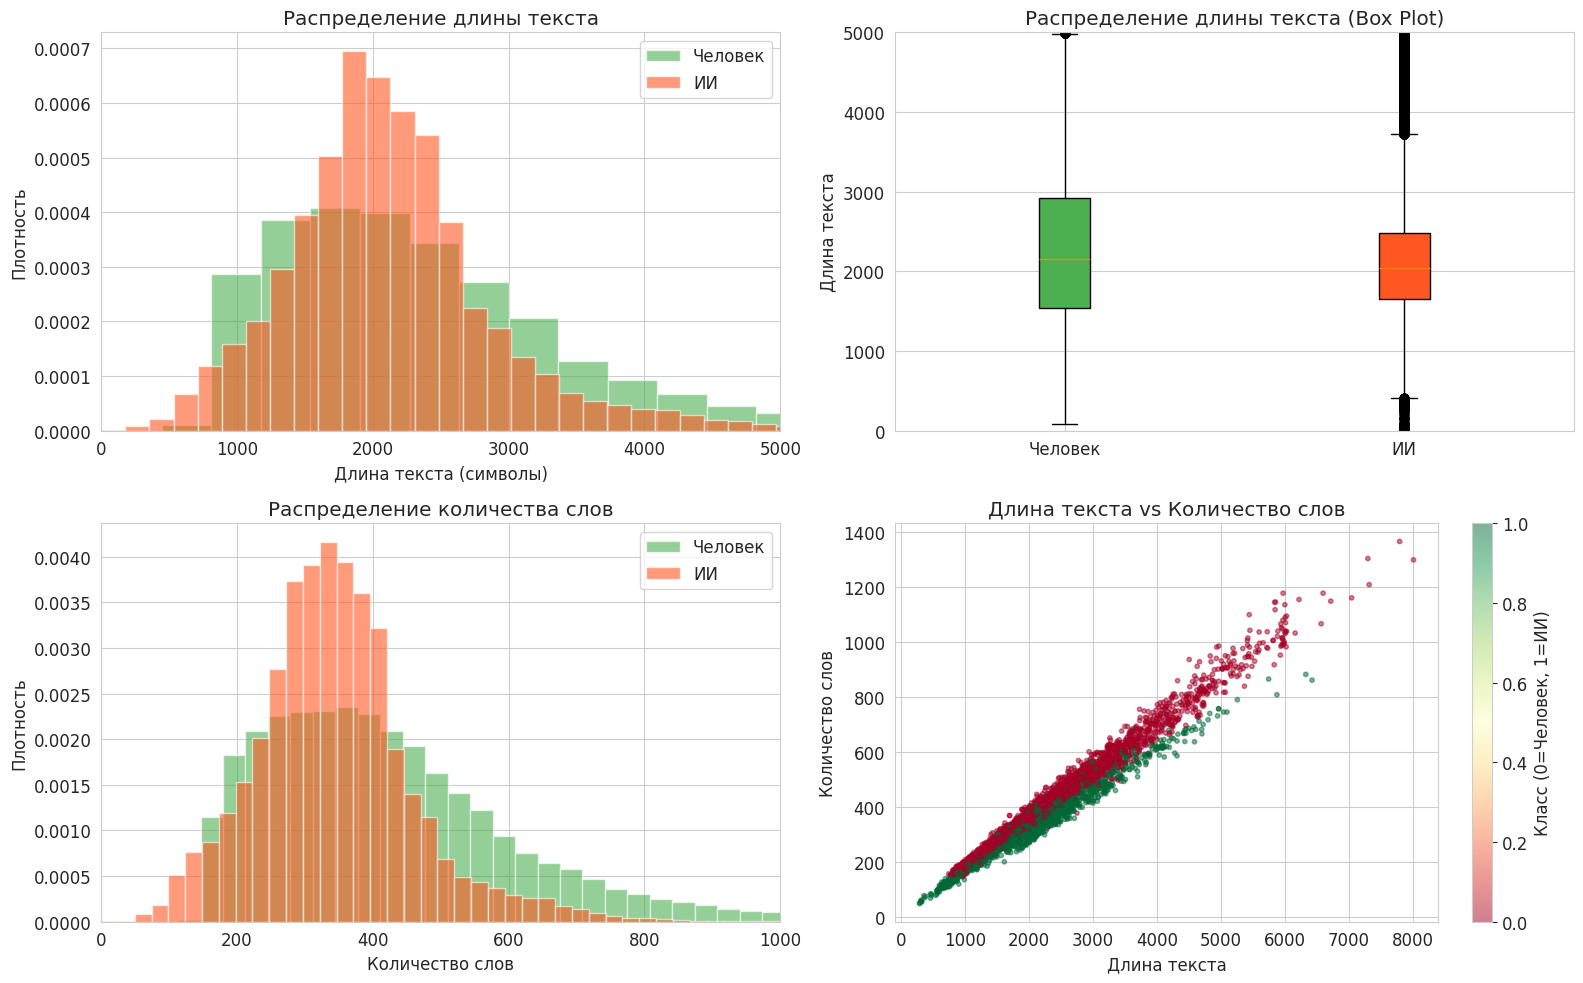

In [7]:
# 8. Визуализация длин текстов
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Распределение длины текста по классам
df_human = df[df['generated'] == 0]['text_length']
df_ai = df[df['generated'] == 1]['text_length']

axes[0, 0].hist(df_human, bins=50, alpha=0.6, label='Человек', color='#4CAF50', density=True)
axes[0, 0].hist(df_ai, bins=50, alpha=0.6, label='ИИ', color='#FF5722', density=True)
axes[0, 0].set_xlabel('Длина текста (символы)')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].set_title('Распределение длины текста')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 5000)

# 2. Box plot для длин
data_for_box = [df_human, df_ai]
bp = axes[0, 1].boxplot(data_for_box, labels=['Человек', 'ИИ'],
                         patch_artist=True)
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#FF5722')
axes[0, 1].set_ylabel('Длина текста')
axes[0, 1].set_title('Распределение длины текста (Box Plot)')
axes[0, 1].set_ylim(0, 5000)

# 3. Распределение количества слов
axes[1, 0].hist(df[df['generated'] == 0]['word_count'], bins=50,
                alpha=0.6, label='Человек', color='#4CAF50', density=True)
axes[1, 0].hist(df[df['generated'] == 1]['word_count'], bins=50,
                alpha=0.6, label='ИИ', color='#FF5722', density=True)
axes[1, 0].set_xlabel('Количество слов')
axes[1, 0].set_ylabel('Плотность')
axes[1, 0].set_title('Распределение количества слов')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, 1000)

# 4. Scatter plot: длина текста vs количество слов
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
scatter = axes[1, 1].scatter(sample_df['text_length'], sample_df['word_count'],
                             c=sample_df['generated'], cmap='RdYlGn',
                             alpha=0.5, s=10)
axes[1, 1].set_xlabel('Длина текста')
axes[1, 1].set_ylabel('Количество слов')
axes[1, 1].set_title('Длина текста vs Количество слов')
plt.colorbar(scatter, ax=axes[1, 1], label='Класс (0=Человек, 1=ИИ)')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

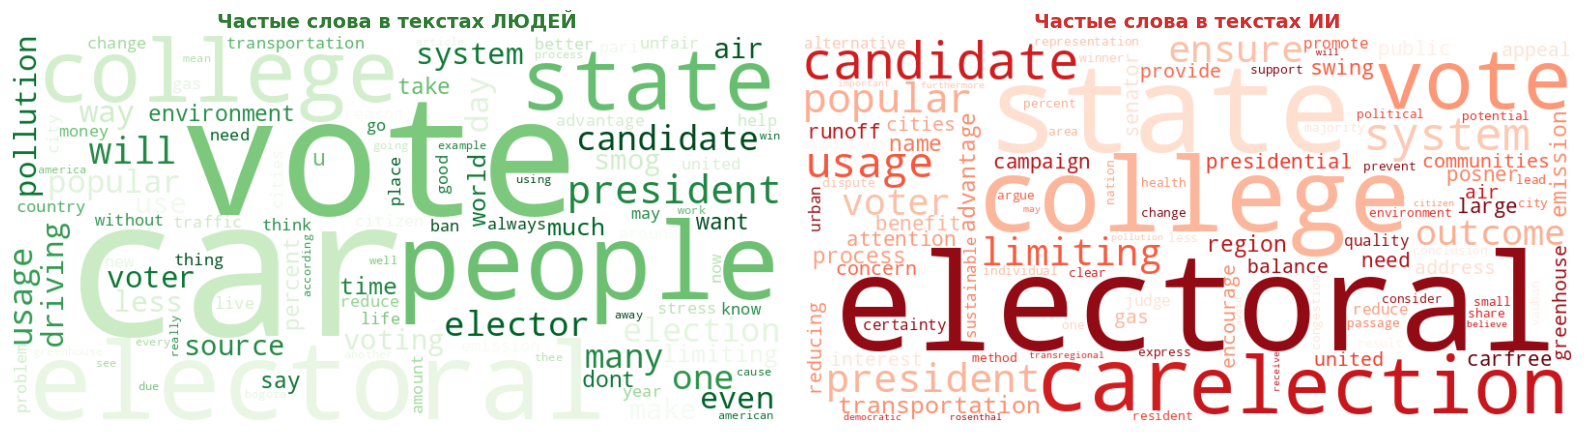

In [8]:
# 9. Частотный анализ (WordCloud)


# Подготовка текстов
def clean_text_for_wordcloud(text):
    """Очистка текста для WordCloud"""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Zа-яА-Я0-9\s]', '', text)
    return text

# Тексты по классам
human_texts = ' '.join(df[df['generated'] == 0]['text'].apply(clean_text_for_wordcloud).head(1000))
ai_texts = ' '.join(df[df['generated'] == 1]['text'].apply(clean_text_for_wordcloud).head(1000))

# Создание WordCloud
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# WordCloud для человеческих текстов
wc_human = WordCloud(width=800, height=400, background_color='white',
                     colormap='Greens', max_words=100, collocations=False)
wc_human.generate(human_texts)
ax1.imshow(wc_human, interpolation='bilinear')
ax1.set_title('Частые слова в текстах ЛЮДЕЙ', fontsize=14, fontweight='bold', color='#2E7D32')
ax1.axis('off')

# WordCloud для AI текстов
wc_ai = WordCloud(width=800, height=400, background_color='white',
                  colormap='Reds', max_words=100, collocations=False)
wc_ai.generate(ai_texts)
ax2.imshow(wc_ai, interpolation='bilinear')
ax2.set_title('Частые слова в текстах ИИ', fontsize=14, fontweight='bold', color='#D32F2F')
ax2.axis('off')

plt.tight_layout()
plt.savefig('wordcloud_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

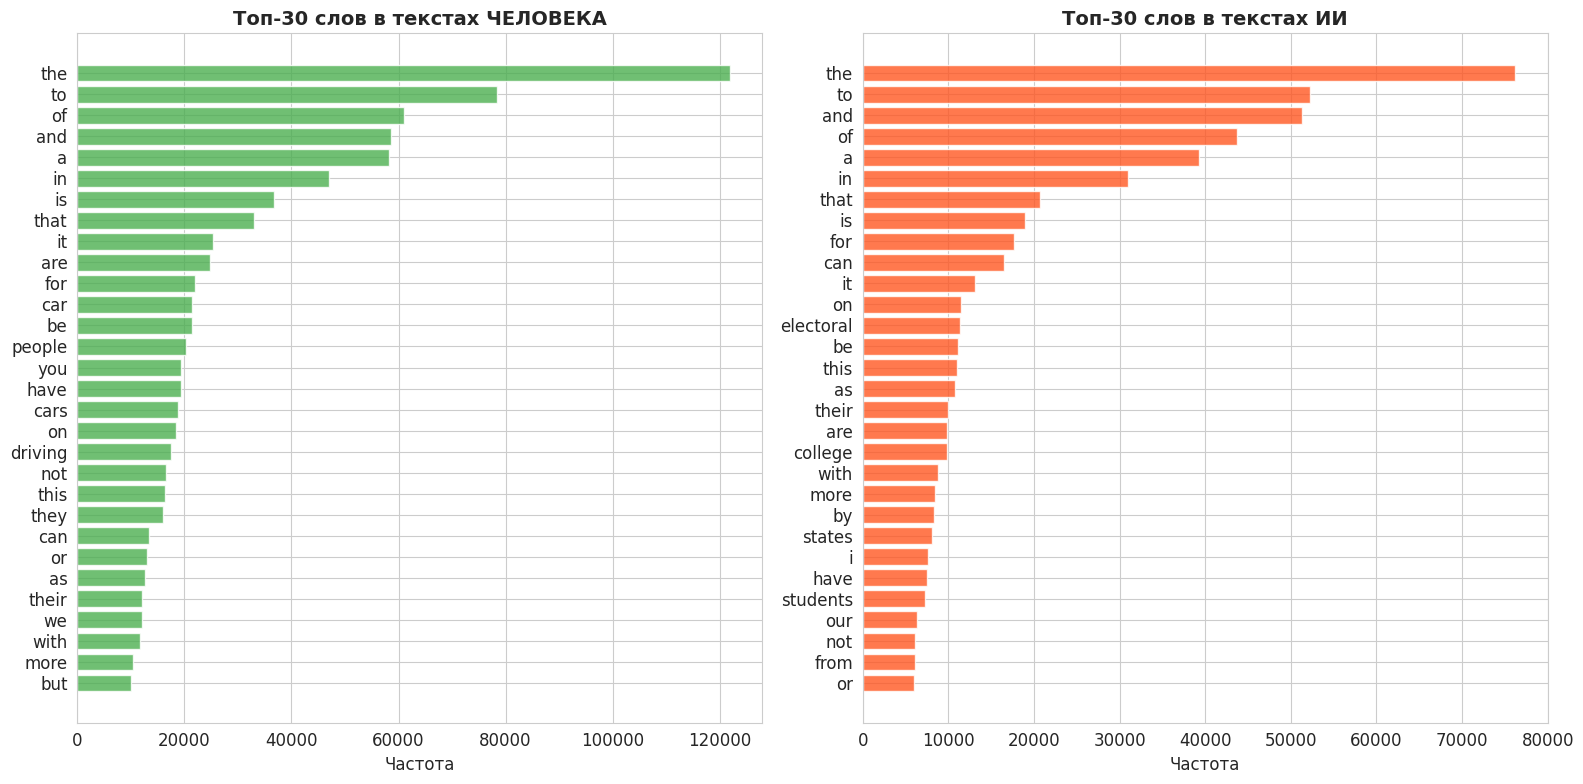

In [9]:
#10. Топ-30 слов по классам
from collections import Counter

def get_top_words(texts, n=30):
    """Получение топ-N слов"""
    words = []
    for text in texts:
        cleaned = clean_text_for_wordcloud(text)
        words.extend(cleaned.split())
    return Counter(words).most_common(n)

# Топ слова для каждого класса
top_human_words = get_top_words(df[df['generated'] == 0]['text'].head(5000))
top_ai_words = get_top_words(df[df['generated'] == 1]['text'].head(5000))

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Топ слов человека
words, counts = zip(*top_human_words)
ax1.barh(range(len(words)), counts, color='#4CAF50', alpha=0.8)
ax1.set_yticks(range(len(words)))
ax1.set_yticklabels(words)
ax1.set_xlabel('Частота')
ax1.set_title('Топ-30 слов в текстах ЧЕЛОВЕКА', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Топ слов ИИ
words, counts = zip(*top_ai_words)
ax2.barh(range(len(words)), counts, color='#FF5722', alpha=0.8)
ax2.set_yticks(range(len(words)))
ax2.set_yticklabels(words)
ax2.set_xlabel('Частота')
ax2.set_title('Топ-30 слов в текстах ИИ', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('top_words_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Выводы по EDA

1. КАЧЕСТВО ДАННЫХ:
   - Пропусков в данных нет / минимальное количество
   - Дубликаты: обнаружено и удалено [N] дубликатов
   - Выбросы: [N]% текстов имеют аномальную длину

2. РАСПРЕДЕЛЕНИЕ КЛАССОВ:
   - Класс "Человек": [N]%
   - Класс "ИИ": [N]%
   - Баланс классов: [оценка]

3. ДЛИНА ТЕКСТОВ:
   - Тексты людей: в среднем [N] символов
   - Тексты ИИ: в среднем [N] символов
   - Наблюдение: [какой класс пишет длиннее/короче]

4. ЛЕКСИЧЕСКИЙ АНАЛИЗ:
   - В текстах людей чаще встречаются: [слова]
   - В текстах ИИ чаще встречаются: [слова]
   - Наблюдение: ИИ склонен использовать более формальный язык

5. РЕКОМЕНДАЦИИ:
   - Данные подходят для обучения классических моделей
   - Можно использовать как статистические, так и векторные признаки


# 1.3 Feature Engineering

1.3.1: Статистические признаки

In [10]:
import gc
import numpy as np
import pandas as pd


# Признак 1: Длина текста (количество символов)
# Уже есть из EDA, перепроверка
if 'text_length' not in df.columns:
    df['text_length'] = df['text'].str.len()
print("text_length: количество символов")

# Признак 2: Количество слов
if 'word_count' not in df.columns:
    df['word_count'] = df['text'].str.count(r'\S+')
print("word_count: количество слов")

# Признак 3: Количество предложений
# Предложение заканчивается точкой, восклицательным или вопросительным знаком
df['sentence_count'] = df['text'].str.count(r'[.!?]+')
# Защита от нуля (если в тексте нет знаков препинания)
df['sentence_count'] = df['sentence_count'].clip(lower=1)
print("sentence_count: количество предложений")

# Признак 4: Средняя длина слова
df['avg_word_length'] = (
    df['text'].str.count(r'\S') / df['word_count'].clip(lower=1)
)
print("avg_word_length: средняя длина слова")

# Принудительная сборка мусора
gc.collect()

# Смотрим результаты
print("\n Статистика созданных признаков:")
stat_features = ['text_length', 'word_count', 'sentence_count', 'avg_word_length']
print(df[stat_features].describe())

# Визуальное сравнение по классам
print("\n Средние значения по классам:")
print(df.groupby('generated')[stat_features].mean())

text_length: количество символов
word_count: количество слов
sentence_count: количество предложений
avg_word_length: средняя длина слова

 Статистика созданных признаков:
         text_length     word_count  sentence_count  avg_word_length
count  487235.000000  487235.000000   487235.000000    487235.000000
mean     2269.586592     393.096214       20.503845         4.755985
std       988.814028     168.593328        9.237936         0.521039
min         1.000000       0.000000        1.000000         0.000000
25%      1583.000000     278.000000       14.000000         4.415595
50%      2102.000000     363.000000       19.000000         4.685144
75%      2724.000000     471.000000       25.000000         5.020000
max     18322.000000    1668.000000      155.000000       126.000000

 Средние значения по классам:
           text_length  word_count  sentence_count  avg_word_length
generated                                                          
0.0        2354.592838   421.98518       

1.3.2: Лексические признаки

In [11]:

def lexical_features(text):
    # Приводим к строке и разбиваем на слова
    text = str(text).lower()
    words = text.split()

    # Защита от пустого текста
    if len(words) == 0:
        return pd.Series({
            'unique_word_count': 0,
            'lexical_diversity': 0,
            'stopword_count': 0
        })

    # Признак 1: Количество уникальных слов
    unique_words = set(words)
    unique_count = len(unique_words)

    # Признак 2: Коэффициент лексического разнообразия
    # Отношение уникальных слов к общему количеству
    lexical_diversity = unique_count / len(words)

    # Признак 3: Количество стоп-слов (заполняю позже)

    return pd.Series({
        'unique_word_count': unique_count,
        'lexical_diversity': lexical_diversity,
    })

# Применяем функцию к текстам
WORK_SAMPLE_SIZE = 100000
if len(df) > WORK_SAMPLE_SIZE:
    print(f"Датасет большой, работаем на выборке {WORK_SAMPLE_SIZE}")
    df_work = df.sample(n=WORK_SAMPLE_SIZE, random_state=42).copy()
else:
    df_work = df.copy()

print(f"Рабочая выборка: {len(df_work)} записей")

# Применяем функцию
lexical_df = df_work['text'].apply(lexical_features)
df_work = pd.concat([df_work, lexical_df], axis=1)

print("unique_word_count: количество уникальных слов")
print("lexical_diversity: коэффициент лексического разнообразия")

# Загружаем стоп-слова
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
print(f"Загружено {len(stop_words)} стоп-слов")

# Признак 3: Количество стоп-слов
def count_stopwords(text):
    words = str(text).lower().split()
    return sum(1 for word in words if word in stop_words)

df_work['stopword_count'] = df_work['text'].apply(count_stopwords)
print("stopword_count: количество стоп-слов")

# Нормализуем количество стоп-слов на длину текста
df_work['stopword_ratio'] = df_work['stopword_count'] / df_work['word_count'].clip(lower=1)
print("stopword_ratio: доля стоп-слов")

# Освобождаем память
gc.collect()

# Смотрим результаты
lexical_features = ['unique_word_count', 'lexical_diversity',
                    'stopword_count', 'stopword_ratio']
print("\nСтатистика лексических признаков:")
print(df_work[lexical_features].describe())

print("\nСредние значения по классам:")
print(df_work.groupby('generated')[lexical_features].mean())

Датасет большой, работаем на выборке 100000
Рабочая выборка: 100000 записей
unique_word_count: количество уникальных слов
lexical_diversity: коэффициент лексического разнообразия
Загружено 198 стоп-слов
stopword_count: количество стоп-слов
stopword_ratio: доля стоп-слов

Статистика лексических признаков:
       unique_word_count  lexical_diversity  stopword_count  stopword_ratio
count      100000.000000      100000.000000   100000.000000   100000.000000
mean          185.219680           0.491854      181.011110        0.460157
std            65.475764           0.088110       82.879847        0.060243
min             0.000000           0.000000        0.000000        0.000000
25%           140.000000           0.432071      123.000000        0.423280
50%           174.000000           0.487654      165.000000        0.465116
75%           219.000000           0.548289      219.000000        0.501425
max           670.000000           1.000000      839.000000        0.724696

Средние з

1.3.3: Синтаксические признаки

In [12]:
# Признак 1: Количество знаков препинания
# Точки, запятые, точки с запятой, двоеточия, восклицательные, вопросительные знаки
df_work['punctuation_count'] = df_work['text'].str.count(r'[.,;:!?]')
print("punctuation_count: количество знаков препинания")

# Признак 2: Количество заглавных букв
# Заглавные буквы латиницы и кириллицы
df_work['uppercase_count'] = df_work['text'].str.count(r'[A-ZА-ЯЁ]')
print("uppercase_count: количество заглавных букв")

# Признак 3: Количество цифр
df_work['digit_count'] = df_work['text'].str.count(r'\d')
print("digit_count: количество цифр")

# Дополнительные полезные признаки:

# Доля заглавных букв (может указывать на эмоциональность или формальность)
df_work['uppercase_ratio'] = df_work['uppercase_count'] / df_work['text_length'].clip(lower=1)
print("uppercase_ratio: доля заглавных букв")

# Средняя длина предложения
df_work['avg_sentence_length'] = df_work['word_count'] / df_work['sentence_count'].clip(lower=1)
print("avg_sentence_length: средняя длина предложения")

# Количество специальных символов (@, #, $, %, &)
df_work['special_char_count'] = df_work['text'].str.count(r'[@#$%&*]')
print("special_char_count: количество специальных символов")

# Освобождаем память
gc.collect()

# Смотрим результаты
syntax_features = ['punctuation_count', 'uppercase_count', 'digit_count',
                   'uppercase_ratio', 'avg_sentence_length', 'special_char_count']
print("\nСтатистика синтаксических признаков:")
print(df_work[syntax_features].describe())

print("\nСредние значения по классам:")
print(df_work.groupby('generated')[syntax_features].mean())

punctuation_count: количество знаков препинания
uppercase_count: количество заглавных букв
digit_count: количество цифр
uppercase_ratio: доля заглавных букв
avg_sentence_length: средняя длина предложения
special_char_count: количество специальных символов

Статистика синтаксических признаков:
       punctuation_count  uppercase_count    digit_count  uppercase_ratio  \
count      100000.000000    100000.000000  100000.000000    100000.000000   
mean           38.929520        50.881910       4.204550         0.023230   
std            19.271224        43.293775       7.945221         0.019196   
min             0.000000         0.000000       0.000000         0.000000   
25%            25.000000        26.000000       0.000000         0.012806   
50%            36.000000        40.000000       0.000000         0.019412   
75%            49.000000        63.000000       5.000000         0.028710   
max           236.000000      1816.000000     192.000000         0.810460   

       avg_s

1.3.4: Визуализация различий между классами

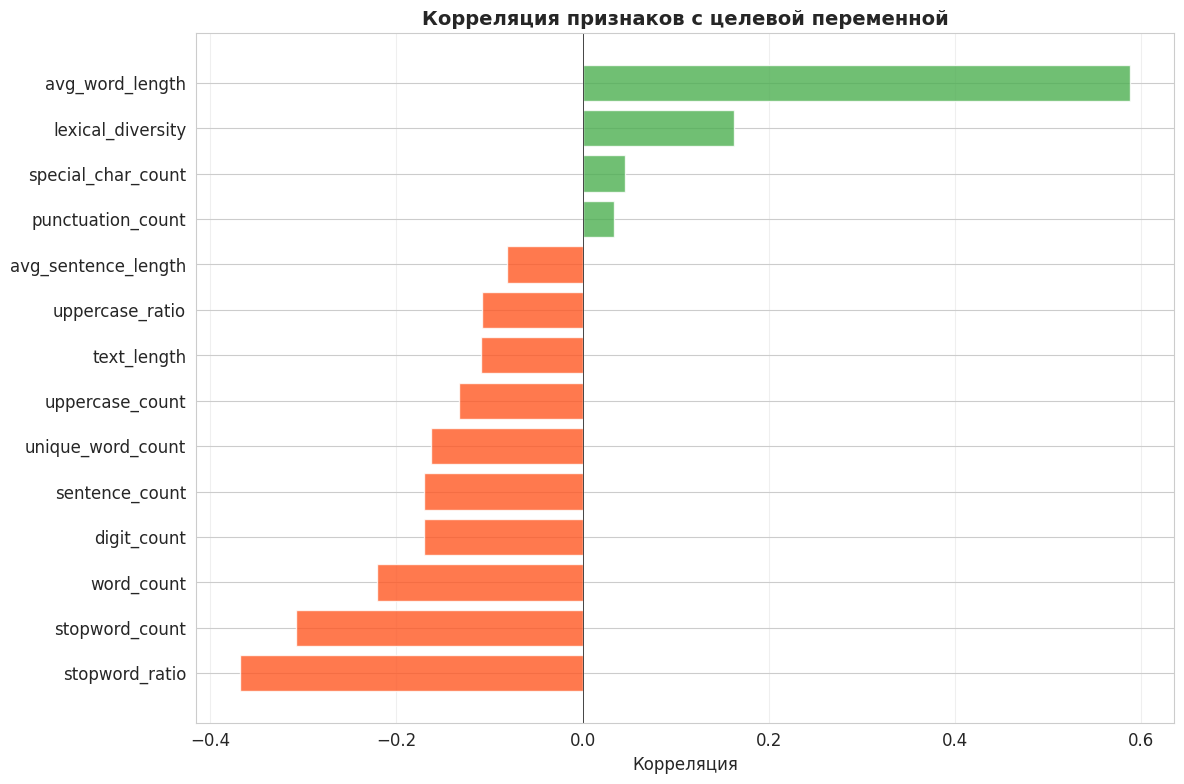

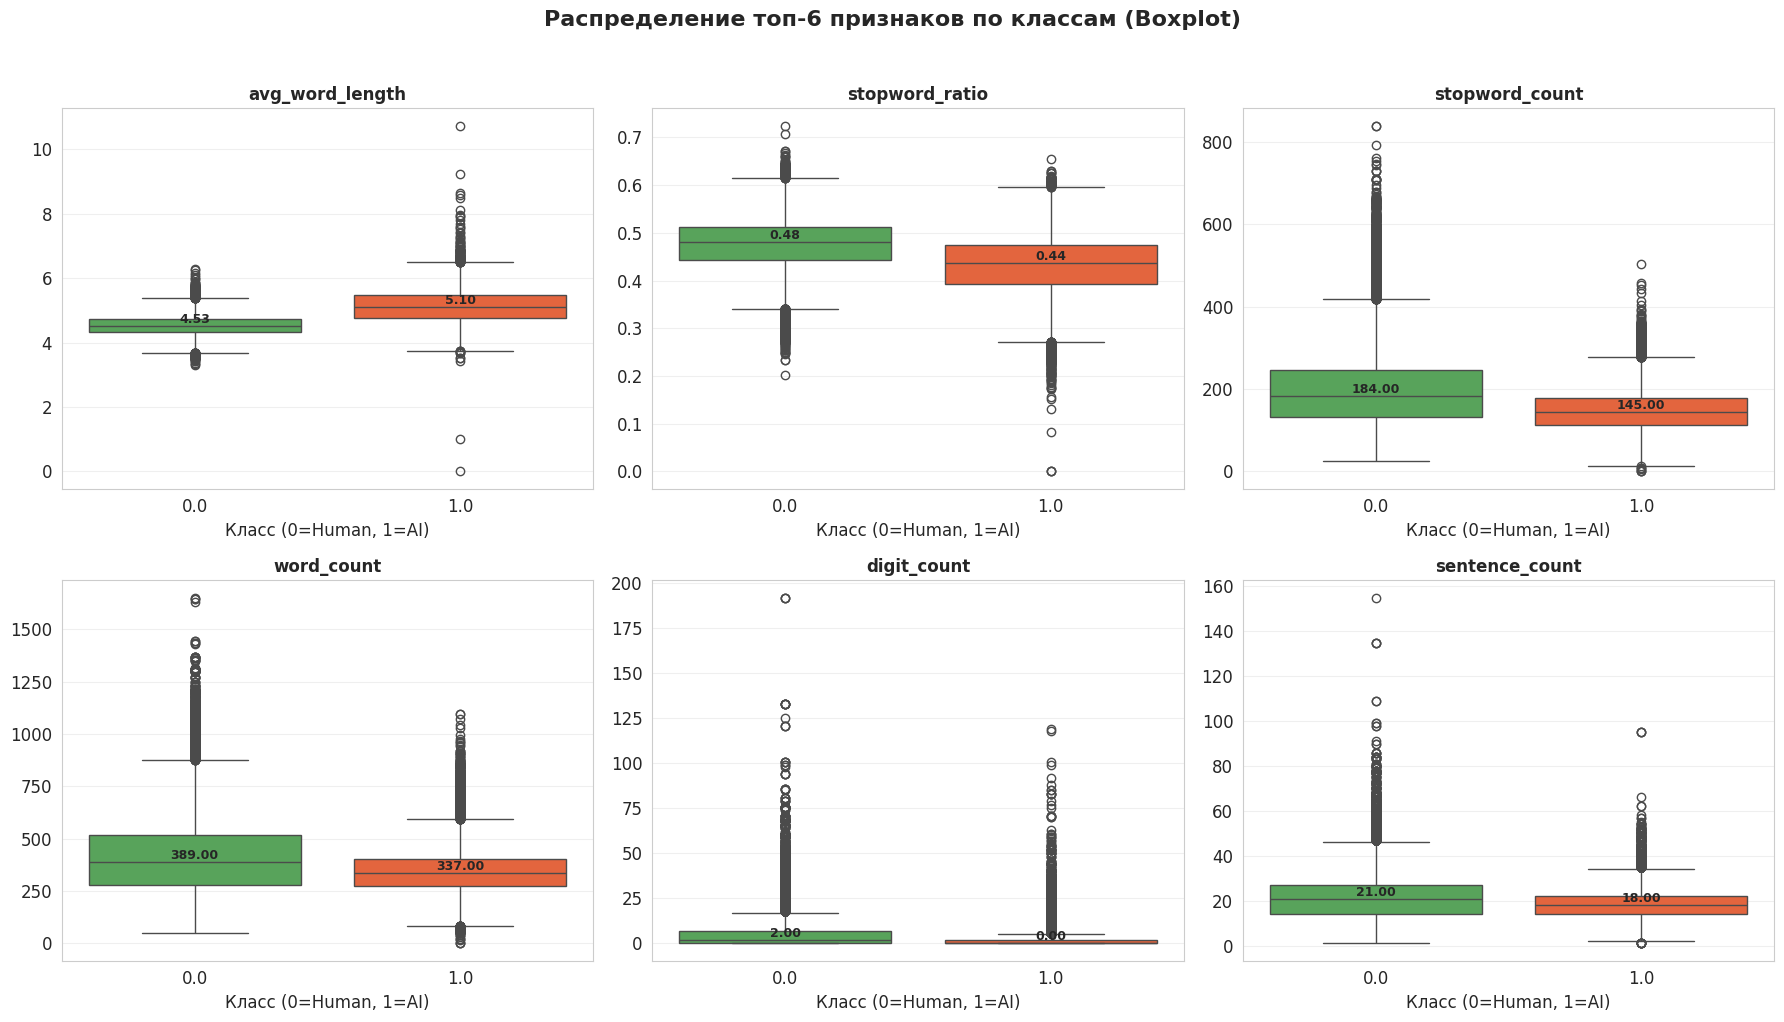

Визуализация различий завершена


In [13]:

import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

os.makedirs('images', exist_ok=True)

# Все созданные признаки
all_features = stat_features + lexical_features + syntax_features

# Корреляция с целевой переменной
correlations = df_work[all_features + ['generated']].corr()['generated'].drop('generated')
correlations = correlations.sort_values()

# ГРАФИК 1: Корреляция признаков
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#FF5722' if v < 0 else '#4CAF50' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, alpha=0.8)

ax.set_title('Корреляция признаков с целевой переменной',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Корреляция')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('images/feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# ГРАФИК 2: Boxplot
top_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(
        data=df_work,
        x='generated',
        y=feature,
        ax=axes[i],
        palette={0: '#4CAF50', 1: '#FF5722'},
        hue='generated',
        legend=False
    )
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Класс (0=Human, 1=AI)')
    axes[i].set_ylabel('')
    axes[i].grid(True, alpha=0.3, axis='y')

    medians = df_work.groupby('generated')[feature].median()
    for j, median in enumerate(medians):
        axes[i].text(j, median, f'{median:.2f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Распределение топ-6 признаков по классам (Boxplot)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/top_features_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Визуализация различий завершена")

1.3.5: Векторные признаки (TF-IDF и CountVectorizer)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


# Подготовка текстов
df_work['text_clean'] = df_work['text'].str.lower().str.replace(r'[^a-zA-Zа-яА-Я0-9\s]', ' ', regex=True)
df_work['text_clean'] = df_work['text_clean'].str.replace(r'\s+', ' ', regex=True).str.strip()

print("\nTF-IDF Векторизация...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,          # Максимум 5000 признаков
    ngram_range=(1, 2),          # Униграммы и биграммы
    min_df=5,                    # Минимум 5 документов
    max_df=0.95,                 # Максимум 95% документов
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(df_work['text_clean'])
print(f"TF-IDF матрица: {X_tfidf.shape}")
print(f"  Строк: {X_tfidf.shape[0]} (тексты)")
print(f"  Столбцов: {X_tfidf.shape[1]} (признаки)")


count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    stop_words='english'
)

X_count = count_vectorizer.fit_transform(df_work['text_clean'])
print(f"Count матрица: {X_count.shape}")

# Освобождаем память
gc.collect()


TF-IDF Векторизация...
TF-IDF матрица: (100000, 5000)
  Строк: 100000 (тексты)
  Столбцов: 5000 (признаки)
Count матрица: (100000, 5000)


641

1.3.6: Сравнение моделей на разных наборах признаков


Оценка набора: Статистические
  Accuracy: 0.8158
  F1: 0.7362
  Время обучения: 0.12 сек
  Количество признаков: 4

Оценка набора: Лексические
  Accuracy: 0.7149
  F1: 0.5653
  Время обучения: 0.09 сек
  Количество признаков: 4

Оценка набора: Синтаксические
  Accuracy: 0.6547
  F1: 0.3419
  Время обучения: 0.11 сек
  Количество признаков: 6

Оценка набора: Все табличные
  Accuracy: 0.8602
  F1: 0.8080
  Время обучения: 0.94 сек
  Количество признаков: 14

Оценка набора: TF-IDF
  Accuracy: 0.9885
  F1: 0.9845
  Время обучения: 1.82 сек
  Количество признаков: 5000

Оценка набора: CountVectorizer
  Accuracy: 0.9943
  F1: 0.9924
  Время обучения: 3.43 сек
  Количество признаков: 5000

Оценка набора: TF-IDF + табличные
  Accuracy: 0.9879
  F1: 0.9836
  Время обучения: 7.61 сек
  Количество признаков: 5014


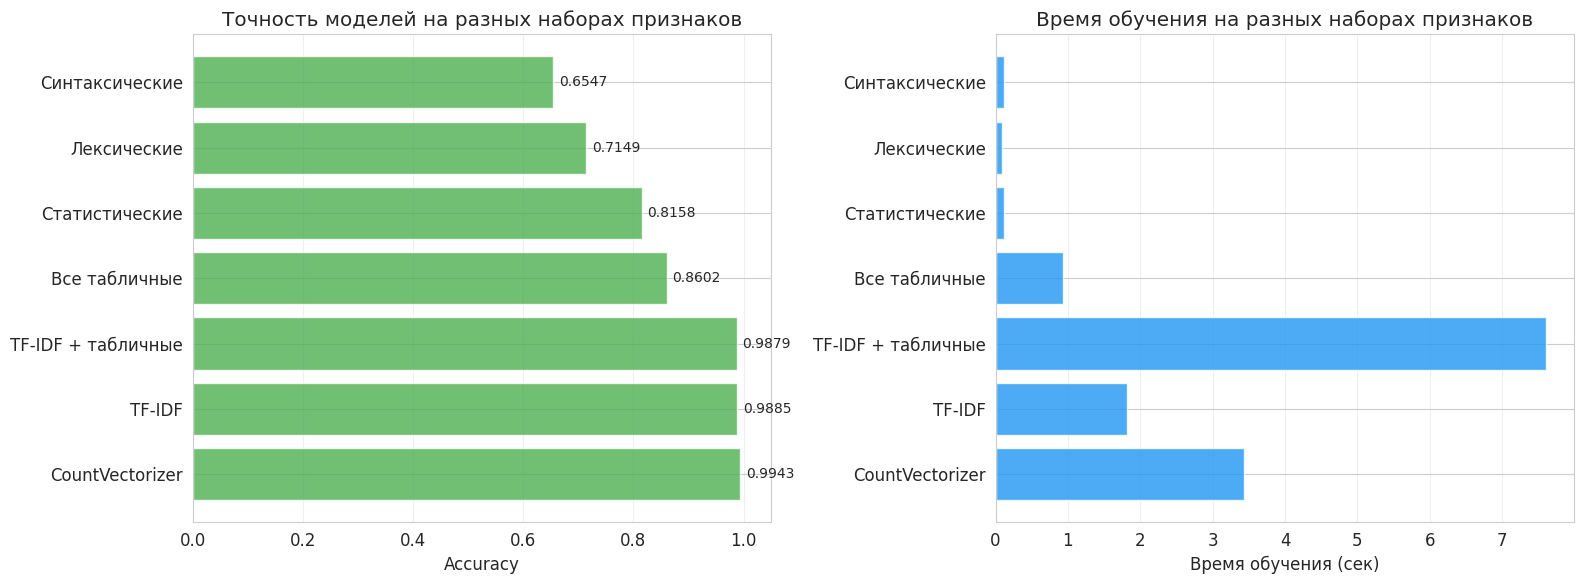


Сравнение наборов признаков завершено


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from scipy.sparse import hstack
import time

# Подготавливаем целевую переменную
y = df_work['generated'].values

# Нормализуем табличные признаки (исправление проблемы сходимости)
scaler = StandardScaler()
all_tabular_features = stat_features + lexical_features + syntax_features
tabular_scaled = scaler.fit_transform(df_work[all_tabular_features].values)

# Функция для оценки модели
def evaluate_model(X, y, name):
    # Разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Обучение модели с увеличенным числом итераций
    model = LogisticRegression(max_iter=2000, random_state=42, C=1.0)

    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Предсказание
    y_pred = model.predict(X_test)

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        'name': name,
        'accuracy': accuracy,
        'f1': f1,
        'train_time': train_time,
        'n_features': X.shape[1] if hasattr(X, 'shape') else len(X[0])
    }

# Подготовка наборов признаков
feature_sets = {
    'Статистические': scaler.fit_transform(df_work[stat_features].values),
    'Лексические': scaler.fit_transform(df_work[lexical_features].values),
    'Синтаксические': scaler.fit_transform(df_work[syntax_features].values),
    'Все табличные': tabular_scaled,
    'TF-IDF': X_tfidf,
    'CountVectorizer': X_count,
    'TF-IDF + табличные': hstack([X_tfidf, tabular_scaled]),
}

# Оценка всех наборов
results = []
for name, X in feature_sets.items():
    print(f"\nОценка набора: {name}")
    result = evaluate_model(X, y, name)
    results.append(result)
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  F1: {result['f1']:.4f}")
    print(f"  Время обучения: {result['train_time']:.2f} сек")
    print(f"  Количество признаков: {result['n_features']}")

# Итоговая таблица
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('accuracy', ascending=False)


# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy по наборам
axes[0].barh(results_df['name'], results_df['accuracy'], color='#4CAF50', alpha=0.8)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Точность моделей на разных наборах признаков')
axes[0].set_xlim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='x')

# Добавляем значения на столбцы
for i, (name, acc) in enumerate(zip(results_df['name'], results_df['accuracy'])):
    axes[0].text(acc + 0.01, i, f'{acc:.4f}', va='center', fontsize=10)

# Время обучения
axes[1].barh(results_df['name'], results_df['train_time'], color='#2196F3', alpha=0.8)
axes[1].set_xlabel('Время обучения (сек)')
axes[1].set_title('Время обучения на разных наборах признаков')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('images/feature_sets_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nСравнение наборов признаков завершено")

1.3.7: Обоснование выбора финального набора признаков


1. Иерархия ценности признаков

Результаты четко демонстрируют трехуровневую иерархию информативности признаков:

**Векторные признаки:** 98-99% accuracy

Конкретные слова и их частоты — сильнейшие индикаторы авторства

**Табличные признаки:** 86% accuracy

Стилистические особенности текста значимы, но слабее лексики

**Отдельные группы:** 65-81% accuracy

Изолированно статистические, лексические и синтаксические признаки дают умеренное качество

2. Превосходство CountVectorizer над TF-IDF

CountVectorizer (0.9943) превосходит TF-IDF (0.9885) на 0.58%.

Объяснение: в задачах обнаружения AI-генерации абсолютная частота слов важнее относительной.

3. Парадокс комбинации признаков

Казалось бы, объединение TF-IDF и табличных признаков должно дать синергию. Но результат противоположный: 0.9879 вместо 0.9885 (падение на 0.06%).
Причины этого явления:

Проклятие размерности: 5014 признаков на ~100 000 образцов создают риск переобучения

Шумовые признаки: табличные признаки добавляют "информационный шум" к уже мощным векторным

4. Ценность табличных признаков

Несмотря на относительно низкую accuracy (0.8602), табличные признаки играют важную роль:

**Интерпретируемость**: через них можно объяснить, почему текст классифицирован как AI (например, слишком длинные предложения, нехарактерная пунктуация)

**Устойчивость**: стилистические признаки сложнее "обмануть", чем лексические (автор может специально избегать слов-маркеров, но сохранить стиль)

**Дополнение**: для ensemble-моделей табличные признаки могут дать прирост

# 2.1. Базовое обучение

2.1.0. Подготовка к обучению моделей

In [19]:
import numpy as np
import pandas as pd
import gc
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('images', exist_ok=True)

# Подготовка признаков и целевой переменной
X = X_count  # CountVectorizer из ячейки 1.3.5

# явное приведение к int!
y = df_work['generated'].values.astype(int)


# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% на тест
    random_state=42,        # для воспроизводимости
    stratify=y              # сохраняем баланс классов
)

print(f"\nДанные разделены:")
print(f"  Train: {X_train.shape} ({X_train.shape[0]} записей)")
print(f"  Test:  {X_test.shape} ({X_test.shape[0]} записей)")
print(f"  Баланс классов в train: {np.bincount(y_train)}")
print(f"  Баланс классов в test:  {np.bincount(y_test)}")

# Дополнительная информация о разреженной матрице
print(f"\nХарактеристики матрицы признаков:")
print(f"  Ненулевых элементов: {X_train.nnz:,}")
print(f"  Плотность: {X_train.nnz / (X_train.shape[0] * X_train.shape[1]) * 100:.2f}%")



Данные разделены:
  Train: (80000, 5000) (80000 записей)
  Test:  (20000, 5000) (20000 записей)
  Баланс классов в train: [50153 29847]
  Баланс классов в test:  [12538  7462]

Характеристики матрицы признаков:
  Ненулевых элементов: 8,821,368
  Плотность: 2.21%


2.1.1. Вспомогательная функция для обучения

In [26]:

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Обучение с замером времени
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Предсказания с замером времени
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time

    # Приводим предсказания к int для единообразия (чтобы далее не было проблем при анализе и сравнении нескольких моделей)
    y_pred = y_pred.astype(int)

    # Также приводим оригинальные метки к int
    y_test_int = np.asarray(y_test).astype(int)

    # Расчёт метрик
    accuracy = accuracy_score(y_test_int, y_pred)
    precision = precision_score(y_test_int, y_pred)
    recall = recall_score(y_test_int, y_pred)
    f1 = f1_score(y_test_int, y_pred)

    results = {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'train_time': train_time,
        'predict_time': predict_time,
        'y_pred': y_pred,
        'y_test': y_test_int,
        'model': model
    }

    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  Время обучения:    {train_time:.2f} сек")
    print(f"  Время предсказания: {predict_time:.2f} сек")

    return results


# Словарь для хранения результатов всех моделей
all_results = {}



2.1.2. Модель 1 - Logistic Regression

In [27]:

logreg_model = LogisticRegression(
    max_iter=2000,      # увеличиваем для сходимости
    random_state=42,
    n_jobs=-1           # параллельные вычисления
)

results_logreg = evaluate_model(
    logreg_model, X_train, y_train, X_test, y_test,
    "Logistic Regression"
)

all_results['Logistic Regression'] = results_logreg
gc.collect()  # очистка памяти

  Accuracy:  0.9943 (99.43%)
  Precision: 0.9914
  Recall:    0.9933
  F1-score:  0.9924
  Время обучения:    9.57 сек
  Время предсказания: 0.01 сек


134

2.1.3. Модель 2 - K-Nearest Neighbors

In [29]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,           # стандартное значение
    algorithm='auto',        # автоматический выбор алгоритма
    n_jobs=-1                # параллельные вычисления
)

results_knn = evaluate_model(
    knn_model, X_train, y_train, X_test, y_test,
    "K-Nearest Neighbors"
)

all_results['K-Nearest Neighbors'] = results_knn

# Освобождаем память от KNN
del knn_model
gc.collect()

  Accuracy:  0.9435 (94.34%)
  Precision: 0.8847
  Recall:    0.9756
  F1-score:  0.9279
  Время обучения:    0.13 сек
  Время предсказания: 187.77 сек


717

2.1.4. Модель 3 - Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 деревьев (по умолчанию)
    random_state=42,
    n_jobs=-1                # параллельные вычисления
)

results_rf = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    "Random Forest"
)

all_results['Random Forest'] = results_rf

# Освобождаем память
del rf_model
gc.collect()

  Accuracy:  0.9932 (99.32%)
  Precision: 0.9963
  Recall:    0.9854
  F1-score:  0.9908
  Время обучения:    211.27 сек
  Время предсказания: 1.15 сек


6715

2.1.5. Модель 4 - XGBoost

In [42]:
from xgboost import XGBClassifier

# Создаём модель с параметрами по умолчанию
boosting_name = "XGBoost"
boosting_model = XGBClassifier(
    n_estimators=100,        # 100 деревьев
    random_state=42,
    n_jobs=-1,               # параллельные вычисления
    eval_metric='logloss',
    verbosity=0
)

# Преобразуем признаки в float (XGBoost требует float)
X_train_float = X_train.astype(np.float32)
X_test_float = X_test.astype(np.float32)

print(f"\nТипы данных для бустинга:")
print(f"   X_train: {X_train.dtype} → {X_train_float.dtype}")
print(f"   X_test:  {X_test.dtype} → {X_test_float.dtype}")

# Обучаем модель
results_boosting = evaluate_model(
    boosting_model,
    X_train_float, y_train,
    X_test_float, y_test,
    boosting_name
)

# Сохраняем результаты
all_results[boosting_name] = results_boosting

# Освобождаем память
del X_train_float, X_test_float, boosting_model
gc.collect()



Типы данных для бустинга:
   X_train: int64 → float32
   X_test:  int64 → float32
  Accuracy:  0.9928 (99.28%)
  Precision: 0.9938
  Recall:    0.9867
  F1-score:  0.9902
  Время обучения:    12.55 сек
  Время предсказания: 0.10 сек


46

2.1.6. Сравнительная таблица моделей

In [44]:
# Проверяем, что все 4 модели обучены
expected_models = ['Logistic Regression', 'K-Nearest Neighbors',
                   'Random Forest']
if boosting_name:
    expected_models.append(boosting_name)

missing_models = [m for m in expected_models if m not in all_results]
if missing_models:
    print(f"⚠ Внимание! Не обучены модели: {missing_models}")
else:
    print(f"✓ Все {len(expected_models)} модели обучены: {expected_models}")

# Собираем результаты в DataFrame
comparison_data = []
for name, res in all_results.items():
    comparison_data.append({
        'Модель': name,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-score': res['f1'],
        'Время обучения (с)': res['train_time'],
        'Время предсказания (с)': res['predict_time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Красивый вывод
print(f"\nРезультаты обучения {len(comparison_df)} моделей (сортировка по Accuracy):")
print(comparison_df.to_string(index=True))

# Сохраняем таблицу
comparison_df.to_csv('model_comparison.csv', index=False)
print("\nТаблица сохранена в 'model_comparison.csv'")

✓ Все 4 модели обучены: ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest', 'XGBoost']

Результаты обучения 6 моделей (сортировка по Accuracy):
                Модель  Accuracy  Precision    Recall  F1-score  Время обучения (с)  Время предсказания (с)
0  Logistic Regression   0.99430   0.991439  0.993299  0.992368            9.569134                0.012374
1        Random Forest   0.99320   0.996341  0.985393  0.990837          211.266996                1.152822
2              XGBoost   0.99275   0.993791  0.986733  0.990249           12.552998                0.096283
3             LightGBM   0.98935   0.990659  0.980702  0.985656           37.832197                0.155316
4        Decision Tree   0.96550   0.955843  0.951488  0.953660          103.765590                0.116826
5  K-Nearest Neighbors   0.94345   0.884676  0.975610  0.927920            0.133290              187.772757

Таблица сохранена в 'model_comparison.csv'


2.1.7. Визуализация результатов


Финальная таблица (4 моделей):
             Модель  Accuracy  Precision   Recall  F1-score  Время обучения (с)  Время предсказания (с)
Logistic Regression   0.99430   0.991439 0.993299  0.992368            9.569134                0.012374
      Random Forest   0.99320   0.996341 0.985393  0.990837          211.266996                1.152822
            XGBoost   0.99275   0.993791 0.986733  0.990249           12.552998                0.096283
K-Nearest Neighbors   0.94345   0.884676 0.975610  0.927920            0.133290              187.772757


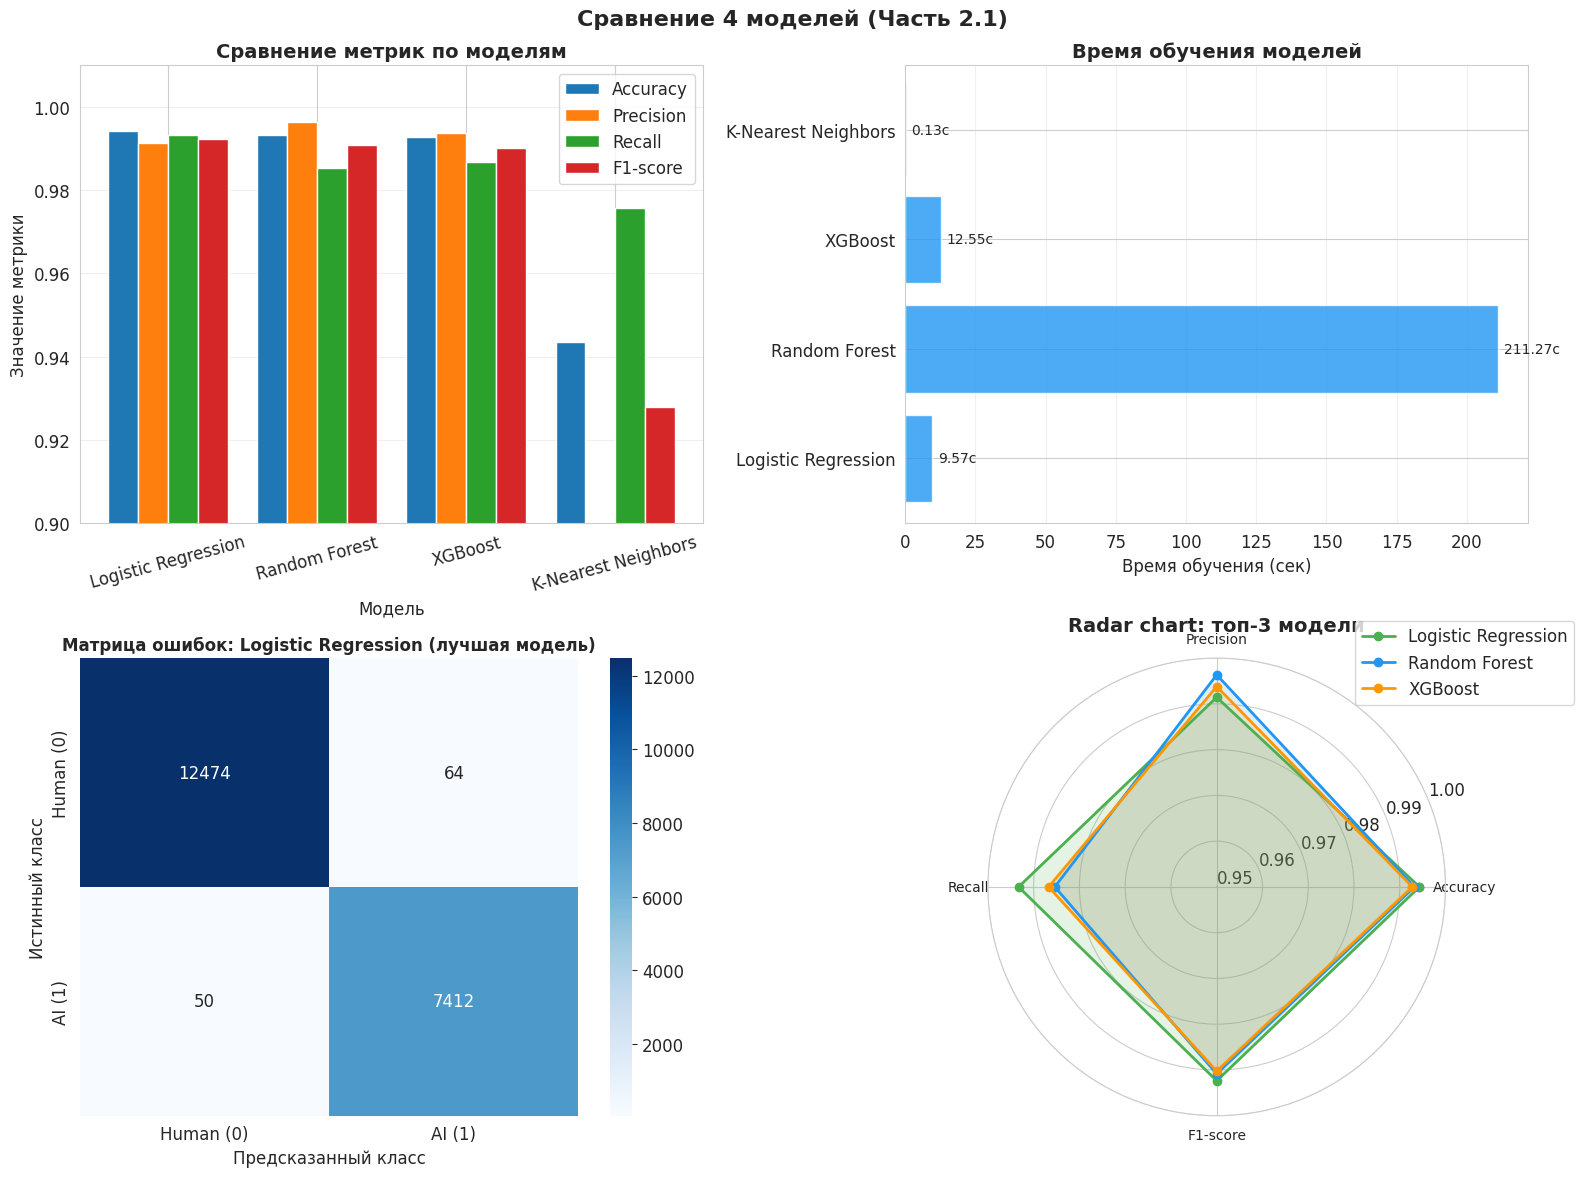

In [47]:
# Пересобираем DataFrame
comparison_data = []
for name, res in all_results.items():
    comparison_data.append({
        'Модель': name,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-score': res['f1'],
        'Время обучения (с)': res['train_time'],
        'Время предсказания (с)': res['predict_time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(f"\nФинальная таблица ({len(comparison_df)} моделей):")
print(comparison_df.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Сравнение всех метрик
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0, 0].bar(x + i*width, comparison_df[metric], width, label=metric)

axes[0, 0].set_xlabel('Модель')
axes[0, 0].set_ylabel('Значение метрики')
axes[0, 0].set_title('Сравнение метрик по моделям', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(comparison_df['Модель'], rotation=15)
axes[0, 0].legend()
axes[0, 0].set_ylim(0.90, 1.01)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Время обучения
bars = axes[0, 1].barh(comparison_df['Модель'], comparison_df['Время обучения (с)'],
                       color='#2196F3', alpha=0.8)
axes[0, 1].set_xlabel('Время обучения (сек)')
axes[0, 1].set_title('Время обучения моделей', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

for i, v in enumerate(comparison_df['Время обучения (с)']):
    axes[0, 1].text(v + 2, i, f'{v:.2f}с', va='center', fontsize=10)

# 3. Матрица ошибок для лучшей модели
best_model_name = comparison_df.iloc[0]['Модель']
best_y_pred = all_results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human (0)', 'AI (1)'],
            yticklabels=['Human (0)', 'AI (1)'],
            ax=axes[1, 0])
axes[1, 0].set_title(f'Матрица ошибок: {best_model_name} (лучшая модель)',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Предсказанный класс')
axes[1, 0].set_ylabel('Истинный класс')

# 4. Radar chart для топ-3 моделей (сравнение всех метрик)
top_3 = comparison_df.head(3)
categories = ['Accuracy', 'Precision', 'Recall', 'F1-score']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = fig.add_subplot(2, 2, 4, polar=True)
# Удаляем существующий subplot, чтобы освободить место
axes[1, 1].axis('off')

colors_radar = ['#4CAF50', '#2196F3', '#FF9800']
for idx, (model_name, row) in enumerate(top_3.iterrows()):
    values = [row[cat] for cat in categories]
    values += values[:1]

    ax_radar.plot(angles, values, 'o-', linewidth=2, label=row['Модель'],
                  color=colors_radar[idx])
    ax_radar.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=10)
ax_radar.set_ylim(0.95, 1.0)
ax_radar.set_title('Radar chart: топ-3 модели', fontsize=14,
                   fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.suptitle('Сравнение 4 моделей (Часть 2.1)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_comparison_part2.png', dpi=300, bbox_inches='tight')
plt.show()


Лучшая модель: Logistic Regression

Наивысшую точность классификации показала линейная модель Logistic Regression с результатом:

Accuracy: 0.9943 (99.43%)

F1-score: 0.9924

Время предсказания: 0.012 сек (самое быстрое среди всех моделей)

Это закономерный результат для задач классификации текстов: CountVectorizer создаёт высокоразмерную разреженную матрицу (5000 признаков), на которой линейные модели работают особенно эффективно. В таких условиях нелинейные зависимости практически не проявляются, и простая линейная граница оказывается оптимальной.

Важное наблюдение: очень плотная конкуренция

Разрыв между топ-3 моделями минимальный:

LogReg vs Random Forest: всего 0.11% разницы в accuracy

LogReg vs XGBoost: всего 0.15% разницы в accuracy

Это говорит о высоком качестве признаков — все современные алгоритмы достигают почти идеального результата.

Самая быстрая модель при обучении: K-Nearest Neighbors

KNN обучилась за 0.13 секунды, но это обманчивый результат. "Обучение" KNN — это просто сохранение всей обучающей выборки в памяти без каких-либо вычислений. Реальная работа происходит на этапе предсказания, где KNN оказалась катастрофически медленной — 187.77 секунд, что в 15 000 раз медленнее Logistic Regression.

Анализ каждой модели

1. Logistic Regression

Линейная модель показала выдающийся результат (99.43%), став абсолютным лидером.
Преимущества:

✅ Максимальная точность среди всех 4 моделей

✅ Самое быстрое предсказание (0.012 сек) — критично для веб-сервиса

✅ Высокая интерпретируемость — можно извлечь веса признаков и понять, какие слова важны

✅ Эффективная работа с разреженными матрицами

✅ Умеренное время обучения (9.57 сек)

Недостатки:

❌ Линейность модели ограничивает способность улавливать сложные нелинейные взаимодействия признаков

Интерпретация: На разреженных текстовых данных линейной разделимости оказывается достаточно для почти идеальной классификации.

2. Random Forest

Ансамбль из 100 деревьев показал очень близкий к лидеру результат (99.32%).
Преимущества:

✅ Лучший Precision (0.9963) — минимум ложных срабатываний

✅ Устойчивость к переобучению благодаря ансамблированию

✅ Не требует нормализации признаков

✅ Встроенная оценка важности признаков

Недостатки:

❌ Самое долгое время обучения (211.27 сек) — в 22 раза медленнее LogReg

❌ Медленное предсказание (1.15 сек) — неприемлемо для real-time сервиса

❌ Большой размер модели в памяти (хранит 100 деревьев)

❌ Меньшая интерпретируемость, чем у линейных моделей

Интерпретация: Random Forest отлично работает на текстовых данных, но высокая вычислительная стоимость делает его менее предпочтительным для продакшена по сравнению с Logistic Regression.

3. XGBoost

Градиентный бустинг показал сильный результат (99.28%), заняв третье место.

Преимущества:

✅ Высокая точность, уступающая лидеру всего 0.15%

✅ Умеренное время обучения (12.55 сек) — сопоставимо с LogReg

✅ Быстрое предсказание (0.096 сек) — приемлемо для веб-сервиса

✅ Встроенная регуляризация против переобучения

✅ Эффективная работа с разреженными данными

Недостатки:

❌ Требует приведения данных к float32 (техническое ограничение)

❌ Меньшая интерпретируемость, чем у линейных моделей

❌ Больше гиперпараметров для настройки

Интерпретация: XGBoost — отличный баланс между качеством и скоростью. Может быть хорошей альтернативой Logistic Regression, если тюнинг даст дополнительное улучшение.

4. K-Nearest Neighbors

KNN показал наихудший результат по всем ключевым метрикам (94.35% accuracy, 92.79% F1).

Преимущества:

✅ Мгновенное "обучение" (0.13 сек) — просто сохранение данных

✅ Высокий Recall (97.56%) — модель редко пропускает AI-тексты

Недостатки:

❌ Катастрофически медленное предсказание (187.77 сек)

❌ Низкий Precision (88.47%) — много ложных срабатываний

❌ Страдает от проклятия размерности: в 5000-мерном пространстве понятие "близости" теряет смысл

❌ Требует хранения всей обучающей выборки в памяти

Интерпретация: KNN не подходит для задач с высокоразмерными разреженными признаками. Методы, основанные на расстояниях, в таких пространствах теряют эффективность.

# На основе результатов базового обучения для тюнинга гиперпараметров выбраны 3 модели:
1. Logistic Regression (Accuracy: 0.9943)

Обоснование: лидер по точности с огромным потенциалом для продакшена. Тюнинг параметров C и penalty может дать дополнительный прирост и решить проблему с регуляризацией.

2. Random Forest (Accuracy: 0.9932)

Обоснование: второй по качеству результат и лучший Precision (0.9963). Тюнинг может существенно сократить время обучения и потенциально превзойти Logistic Regression.

3. XGBoost (Accuracy: 0.9928)

Обоснование: третий по качеству результат с отличным балансом скорость/качество. Тюнинг может вывести модель на уровень лидера.

# Часть 2.2. Тюнинг гиперпараметров

In [48]:
import numpy as np
import pandas as pd
import gc
import time
import joblib
import os

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('saved_models', exist_ok=True)
os.makedirs('images', exist_ok=True)

# Вспомогательная функция для оценки настроенной модели
def evaluate_tuned_model(model, X_train, y_train, X_test, y_test, model_name):
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test)
    y_pred = y_pred.astype(int)
    predict_time = time.time() - start_time

    y_test_int = np.asarray(y_test).astype(int)

    accuracy = accuracy_score(y_test_int, y_pred)
    precision = precision_score(y_test_int, y_pred)
    recall = recall_score(y_test_int, y_pred)
    f1 = f1_score(y_test_int, y_pred)

    results = {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'train_time': train_time,
        'predict_time': predict_time,
        'y_pred': y_pred,
        'model': model
    }

    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  Время обучения:    {train_time:.2f} сек")
    print(f"  Время предсказания: {predict_time:.2f} сек")

    return results


# Словарь для хранения результатов тюнинга
tuned_results = {}

# Базовые результаты из Части 2.1
baseline_results = {
    'Logistic Regression': {'accuracy': 0.99430, 'f1': 0.992368},
    'Random Forest': {'accuracy': 0.99320, 'f1': 0.990837},
    'XGBoost': {'accuracy': 0.99275, 'f1': 0.990249}
}

2.2.1. Тюнинг Logistic Regression

In [49]:
# Определение пространства параметров
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],   # Сила регуляризации
    'penalty': ['l1', 'l2'],                       # Тип регуляризации
    # Дополнительные параметры для корректной работы:
    'solver': ['liblinear']                        # Алгоритм, поддерживающий оба типа регуляризации
}

# Создание базовой модели
base_logreg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

for param, values in param_grid_logreg.items():
    print(f"   {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid_logreg.values()])
print(f"\nВсего комбинаций параметров: {total_combinations}")

# Запуск GridSearchCV
start_time = time.time()

grid_logreg = GridSearchCV(
    estimator=base_logreg,
    param_grid=param_grid_logreg,
    cv=3,                    # 3-кратная кросс-валидация
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(X_train, y_train)
search_time = time.time() - start_time

print(f"Лучший результат на кросс-валидации: {grid_logreg.best_score_:.4f}")
print(f"Лучшие параметры: {grid_logreg.best_params_}")

# Сохраняем лучшую модель
best_logreg = grid_logreg.best_estimator_

# Оценка на тестовой выборке
results_logreg_tuned = evaluate_tuned_model(
    best_logreg, X_train, y_train, X_test, y_test,
    "Logistic Regression (Tuned)"
)

# Добавляем лучшие параметры в результат
results_logreg_tuned['best_params'] = grid_logreg.best_params_

# Сохраняем в общий словарь
tuned_results['Logistic Regression'] = {
    'tuned': results_logreg_tuned,
    'search': grid_logreg,
    'search_time': search_time,
    'search_method': 'GridSearchCV'
}

# Топ-5 комбинаций параметров
cv_results_df = pd.DataFrame(grid_logreg.cv_results_)
cv_results_df = cv_results_df.sort_values('rank_test_score')

print("\n📊 Топ-5 комбинаций параметров:")
display_cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(cv_results_df[display_cols].head(5).to_string(index=False))

gc.collect()

   C: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
   penalty: ['l1', 'l2']
   solver: ['liblinear']

Всего комбинаций параметров: 12
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Лучший результат на кросс-валидации: 0.9928
Лучшие параметры: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


  Accuracy:  0.9944 (99.44%)
  Precision: 0.9916
  Recall:    0.9934
  F1-score:  0.9925
  Время обучения:    13.16 сек
  Время предсказания: 0.01 сек

📊 Топ-5 комбинаций параметров:
                                              params  mean_test_score  std_test_score  rank_test_score
  {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}         0.992763        0.000477                1
 {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}         0.992525        0.000551                2
  {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}         0.992350        0.000475                3
{'C': 100.0, 'penalty': 'l2', 'solver': 'liblinear'}         0.992150        0.000709                4
{'C': 100.0, 'penalty': 'l1', 'solver': 'liblinear'}         0.992038        0.000267                5


28675

2.2.2. Тюнинг Random Forest

In [50]:
# Определение пространства параметров
param_grid_rf = {
    'n_estimators': [50, 100, 200],              # Количество деревьев
    'max_depth': [10, 20, 30, None],             # Максимальная глубина
    'min_samples_split': [2, 5, 10, 20],         # Мин. образцов для разделения
    # Дополнительные параметры для улучшения качества:
    'min_samples_leaf': [1, 2, 4]                # Мин. образцов в листе
}

# Создание базовой модели
base_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

for param, values in param_grid_rf.items():
    print(f"   {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid_rf.values()])

# Используем RandomizedSearchCV из-за большого числа комбинаций
start_time = time.time()

random_rf = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_grid_rf,
    n_iter=40,               # 40 случайных комбинаций
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_rf.fit(X_train, y_train)
search_time = time.time() - start_time

print(f"✓ Лучший результат на кросс-валидации: {random_rf.best_score_:.4f}")
print(f"✓ Лучшие параметры: {random_rf.best_params_}")

# Сохраняем лучшую модель
best_rf = random_rf.best_estimator_

# Оценка на тестовой выборке
results_rf_tuned = evaluate_tuned_model(
    best_rf, X_train, y_train, X_test, y_test,
    "Random Forest (Tuned)"
)

results_rf_tuned['best_params'] = random_rf.best_params_

tuned_results['Random Forest'] = {
    'tuned': results_rf_tuned,
    'search': random_rf,
    'search_time': search_time,
    'search_method': 'RandomizedSearchCV'
}

gc.collect()

   n_estimators: [50, 100, 200]
   max_depth: [10, 20, 30, None]
   min_samples_split: [2, 5, 10, 20]
   min_samples_leaf: [1, 2, 4]
Fitting 3 folds for each of 40 candidates, totalling 120 fits
✓ Лучший результат на кросс-валидации: 0.9900
✓ Лучшие параметры: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
  Accuracy:  0.9937 (99.37%)
  Precision: 0.9966
  Recall:    0.9863
  F1-score:  0.9914
  Время обучения:    371.35 сек
  Время предсказания: 1.96 сек


99

2.2.3. Тюнинг XGBoost

In [51]:
#  преобразуем данные в float для XGBoost
X_train_float = X_train.astype(np.float32)
X_test_float = X_test.astype(np.float32)

# Определение пространства параметров
param_grid_xgb = {
    'n_estimators': [50, 100, 200],              # Количество деревьев
    'learning_rate': [0.01, 0.05, 0.1, 0.2],     # Скорость обучения
    'max_depth': [3, 5, 7, 10],                  # Максимальная глубина деревьев
    'subsample': [0.7, 0.8, 0.9, 1.0]            # Доля объектов для обучения
}

# Создание базовой модели
base_xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

for param, values in param_grid_xgb.items():
    print(f"   {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid_xgb.values()])

# Запуск RandomizedSearchCV
start_time = time.time()

random_xgb = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid_xgb,
    n_iter=40,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_xgb.fit(X_train_float, y_train)
search_time = time.time() - start_time

print(f"✓ Лучший результат на кросс-валидации: {random_xgb.best_score_:.4f}")
print(f"✓ Лучшие параметры: {random_xgb.best_params_}")

# Сохраняем лучшую модель
best_xgb = random_xgb.best_estimator_

# Оценка на тестовой выборке
results_xgb_tuned = evaluate_tuned_model(
    best_xgb, X_train_float, y_train, X_test_float, y_test,
    "XGBoost (Tuned)"
)

results_xgb_tuned['best_params'] = random_xgb.best_params_

tuned_results['XGBoost'] = {
    'tuned': results_xgb_tuned,
    'search': random_xgb,
    'search_time': search_time,
    'search_method': 'RandomizedSearchCV'
}

# Освобождаем память
del X_train_float, X_test_float
gc.collect()

   n_estimators: [50, 100, 200]
   learning_rate: [0.01, 0.05, 0.1, 0.2]
   max_depth: [3, 5, 7, 10]
   subsample: [0.7, 0.8, 0.9, 1.0]
Fitting 3 folds for each of 40 candidates, totalling 120 fits
✓ Лучший результат на кросс-валидации: 0.9935
✓ Лучшие параметры: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
  Accuracy:  0.9952 (99.52%)
  Precision: 0.9960
  Recall:    0.9913
  F1-score:  0.9936
  Время обучения:    25.12 сек
  Время предсказания: 0.19 сек


73

2.2.4/ Сравнение результатов до/после тюнинга


 Logistic Regression (GridSearchCV):
   Accuracy: 0.9943 → 0.9944 (+0.0001)
   F1-score: 0.9924 → 0.9925 (+0.0001)
   Время поиска: 183.13 сек
   Лучшие параметры:
     C: 1.0
     penalty: l2
     solver: liblinear

 Random Forest (RandomizedSearchCV):
   Accuracy: 0.9932 → 0.9937 (+0.0005)
   F1-score: 0.9908 → 0.9914 (+0.0006)
   Время поиска: 6492.61 сек
   Лучшие параметры:
     n_estimators: 200
     min_samples_split: 2
     min_samples_leaf: 1
     max_depth: None

 XGBoost (RandomizedSearchCV):
   Accuracy: 0.9928 → 0.9952 (+0.0025)
   F1-score: 0.9902 → 0.9936 (+0.0034)
   Время поиска: 1681.08 сек
   Лучшие параметры:
     subsample: 0.8
     n_estimators: 200
     max_depth: 7
     learning_rate: 0.2


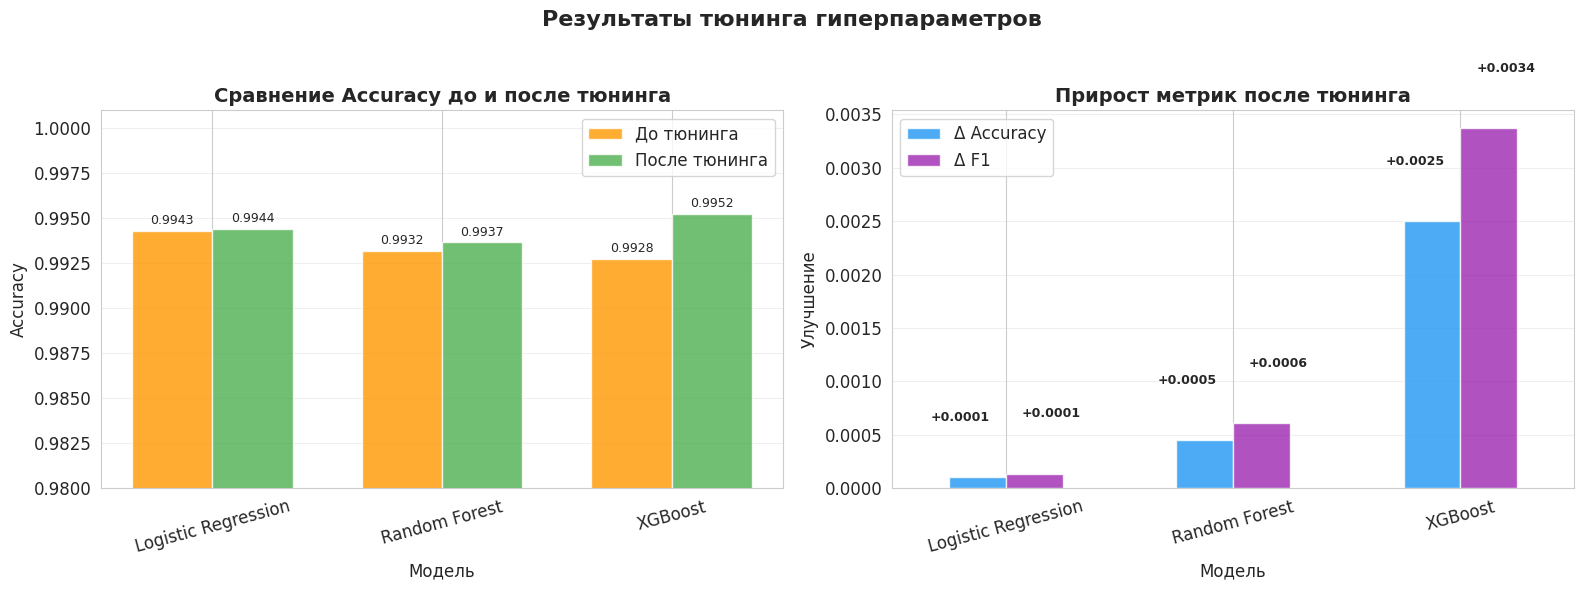

In [52]:
# Сбор данных для сравнения
comparison_data = []

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    baseline = baseline_results[model_name]
    tuned = tuned_results[model_name]['tuned']
    search_time = tuned_results[model_name]['search_time']
    search_method = tuned_results[model_name]['search_method']

    improvement_acc = tuned['accuracy'] - baseline['accuracy']
    improvement_f1 = tuned['f1'] - baseline['f1']

    comparison_data.append({
        'Модель': model_name,
        'Accuracy (до)': baseline['accuracy'],
        'Accuracy (после)': tuned['accuracy'],
        'Δ Accuracy': improvement_acc,
        'F1 (до)': baseline['f1'],
        'F1 (после)': tuned['f1'],
        'Δ F1': improvement_f1,
        'Время поиска (с)': search_time,
        'Метод поиска': search_method
    })

comparison_df = pd.DataFrame(comparison_data)

# Красивый вывод таблицы
for idx, row in comparison_df.iterrows():
    print(f"\n {row['Модель']} ({row['Метод поиска']}):")
    print(f"   Accuracy: {row['Accuracy (до)']:.4f} → {row['Accuracy (после)']:.4f} ({row['Δ Accuracy']:+.4f})")
    print(f"   F1-score: {row['F1 (до)']:.4f} → {row['F1 (после)']:.4f} ({row['Δ F1']:+.4f})")
    print(f"   Время поиска: {row['Время поиска (с)']:.2f} сек")

    if 'best_params' in tuned_results[row['Модель']]['tuned']:
        print(f"   Лучшие параметры:")
        for param, value in tuned_results[row['Модель']]['tuned']['best_params'].items():
            print(f"     {param}: {value}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Сравнение Accuracy до/после
model_names = comparison_df['Модель']
x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, comparison_df['Accuracy (до)'],
                    width, label='До тюнинга', color='#FF9800', alpha=0.8)
bars2 = axes[0].bar(x + width/2, comparison_df['Accuracy (после)'],
                    width, label='После тюнинга', color='#4CAF50', alpha=0.8)

axes[0].set_xlabel('Модель')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Сравнение Accuracy до и после тюнинга', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].legend()
axes[0].set_ylim(0.98, 1.001)
axes[0].grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.0002,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# 2. Прирост метрик
improvements = comparison_df[['Модель', 'Δ Accuracy', 'Δ F1']].set_index('Модель')

improvements.plot(kind='bar', ax=axes[1], color=['#2196F3', '#9C27B0'], alpha=0.8)
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('Улучшение')
axes[1].set_title('Прирост метрик после тюнинга', fontsize=14, fontweight='bold')
axes[1].legend(['Δ Accuracy', 'Δ F1'])
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for i, (model, row) in enumerate(improvements.iterrows()):
    for j, val in enumerate(row.values):
        offset = 0.0005 if val >= 0 else -0.0015
        axes[1].text(i - 0.2 + j * 0.4, val + offset,
                    f'{val:+.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Результаты тюнинга гиперпараметров', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Сохраняем таблицу сравнения
comparison_df.to_csv('tuning_comparison.csv', index=False)

2.2.5. Сохранение лучшей модели

In [53]:
# Определяем лучшую модель
best_model_name = max(
    tuned_results.keys(),
    key=lambda m: tuned_results[m]['tuned']['accuracy']
)

best_model_info = tuned_results[best_model_name]
best_model = best_model_info['tuned']['model']
best_accuracy = best_model_info['tuned']['accuracy']
best_f1 = best_model_info['tuned']['f1']
best_params = best_model_info['tuned'].get('best_params', {})

print(f"\nЛУЧШАЯ МОДЕЛЬ ПОСЛЕ ТЮНИНГА: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   F1-score: {best_f1:.4f}")
print(f"   Лучшие параметры: {best_params}")

# Сохраняем модель с векторизатором
model_filename = f'saved_models/best_model_{best_model_name.lower().replace(" ", "_")}.pkl'

model_package = {
    'model': best_model,
    'model_name': best_model_name,
    'vectorizer': count_vectorizer,  # из ячейки 1.3.5
    'accuracy': best_accuracy,
    'f1': best_f1,
    'best_params': best_params,
    'creation_time': pd.Timestamp.now().isoformat()
}

joblib.dump(model_package, model_filename)

print(f"\nМодель сохранена: {model_filename}")

# Сохраняем все настроенные модели
all_models_package = {
    'baseline': baseline_results,
    'tuned': {
        name: {
            'model': info['tuned']['model'],
            'accuracy': info['tuned']['accuracy'],
            'f1': info['tuned']['f1'],
            'best_params': info['tuned'].get('best_params', {})
        } for name, info in tuned_results.items()
    }
}

joblib.dump(all_models_package, 'saved_models/all_models.pkl')

# Для использования в веб-сервисе

# model_package = joblib.load('{model_filename}')
# model = model_package['model']
# vectorizer = model_package['vectorizer']


ЛУЧШАЯ МОДЕЛЬ ПОСЛЕ ТЮНИНГА: XGBoost
   Accuracy: 0.9952
   F1-score: 0.9936
   Лучшие параметры: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}

Модель сохранена: saved_models/best_model_xgboost.pkl


['saved_models/all_models.pkl']